0 0.040504029239266486
1 0.012596468253802548
2 0.004316318652252913
3 0.0013654477975446717


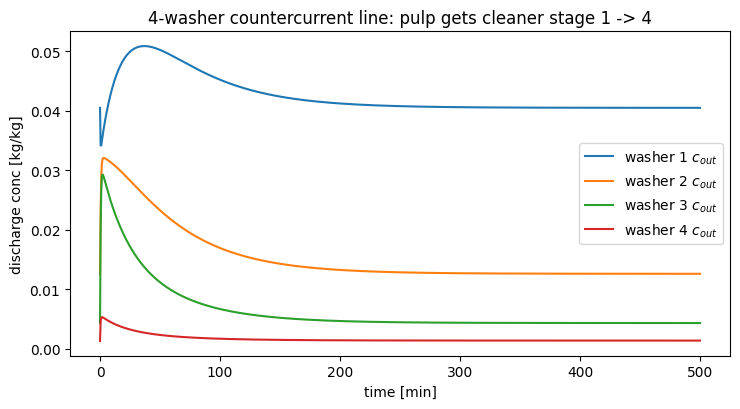

In [13]:
import numpy as np
from scipy.integrate import solve_ivp

# Dictionaries with operating parameters for each washer.

Global = dict(PR = 600.0, WL = 5200.0, c_WL = 0.001)   # WL here = FRESH wash-water rate (enters last washer only)

Washer_1 = dict(N1=0.12, N2=0.012, N3=0.10, N4=0.10, N5=0.13, DR=0.85, tau_d=0.5, m_v_sp=20000.0, m_T_sp=30000.0, Kp_v=5.0, Kp_T=5.0)
Washer_2 = dict(N1=0.12, N2=0.012, N3=0.10, N4=0.10, N5=0.13, DR=0.85, tau_d=0.5, m_v_sp=20000.0, m_T_sp=30000.0, Kp_v=5.0, Kp_T=5.0)
Washer_3 = dict(N1=0.12, N2=0.012, N3=0.10, N4=0.10, N5=0.13, DR=0.85, tau_d=0.5, m_v_sp=20000.0, m_T_sp=30000.0, Kp_v=5.0, Kp_T=5.0)
Washer_4 = dict(N1=0.12, N2=0.012, N3=0.10, N4=0.10, N5=0.13, DR=0.85, tau_d=0.5, m_v_sp=20000.0, m_T_sp=30000.0, Kp_v=5.0, Kp_T=5.0)

class Washer:

    n_states = 5
    state_names = ("m_v", "m_sv", "m_T", "m_sT", "c4")

    def __init__(self, PR, N1, N2, N3, N4, N5, WL, c_WL, DR, tau_d, m_v_sp, m_T_sp, Kp_v, Kp_T):
        self.PR = PR
        self.N = (N1, N2, N3, N4, N5)
        self.DR = DR
        self.tau_d = tau_d
        self.m_v_sp = m_v_sp
        self.m_T_sp = m_T_sp
        self.Kp_v = Kp_v
        self.Kp_T = Kp_T

        # liquor-to-pulp ratio defined by consistency
        r = [(1.0 - n) / n for n in self.N]
        self.L1, self.L2, self.L3, self.L4, self.L5 = [PR * ri for ri in r]

        # nominal control flows that close the steady-state balance (use nominal WL)
        self.L6_nom = self.L2 - self.L1
        self.L9_nom = (self.L2 - self.L3) + (self.L3 + WL - self.L4) + (self.L4 - self.L5)

    # Provides DR value for washing section from the dynamic DR model (DR Model not yet determined, for now 
    # DR is constant)
    def dr(self, c3, c_v, c_T):
        # yet to insert dynamic DR function here
        return self.DR(c3, c_v, c_T) if callable(self.DR) else self.DR

    # outlets of each washer that feeds into neighours 
    def outlets(self, y):
        m_v, m_sv, m_T, m_sT, c4 = y
        c_T = m_sT / m_T
        L6 = max(0.0, self.L6_nom - self.Kp_v * (m_v - self.m_v_sp))
        L9 = max(0.0, self.L9_nom + self.Kp_T * (m_T - self.m_T_sp))
        L10 = L9 - L6
        return dict(c_out=c4, L10=L10, c_T=c_T)   # c_out -> downstream pulp feed; (L10,c_T) -> upstream wash liquor

    # Algebraic Equations
    def algebraic(self, y, inlets):
        m_v, m_sv, m_T, m_sT, c4 = y
        c_v = m_sv / m_v
        c_T = m_sT / m_T
        WL, c_WL = inlets["WL"], inlets["c_WL"]
        L1, L2, L3, L4, L5 = self.L1, self.L2, self.L3, self.L4, self.L5

        # Flow control of recycle to vat (P-only for now)
        L6 = max(0.0, self.L6_nom - self.Kp_v * (m_v - self.m_v_sp))

        # Washing (wash zone)
        c3 = c_v
        F = L3 + WL - L4
        DR = self.dr(c3, c_v, c_T)
        c4_ss = (1.0 - DR) * c3 + DR * c_WL
        c_F = (L3 * c3 + WL * c_WL - L4 * c4) / F

        # Formation / dewatering drainage to the tank
        L7 = L2 - L3
        L8 = L4 - L5

        # Flow control of L9 to maintain seal-tank level (P-only for now)
        L9 = max(0.0, self.L9_nom + self.Kp_T * (m_T - self.m_T_sp))

        # Distributor
        L10 = L9 - L6
        return dict(c_v=c_v, c_T=c_T, c3=c3, c4_ss=c4_ss, c_F=c_F, L6=L6, L7=L7, L8=L8, L9=L9, L10=L10, F=F, DR=DR)

    # ODEs
    def ODEs(self, y, inlets):
        m_v, m_sv, m_T, m_sT, c4 = y
        c_in = inlets["c_in"]
        a = self.algebraic(y, inlets)
        L1, L2 = self.L1, self.L2

        # dilution vat (CSTR)
        dm_v = L1 + a['L6'] - L2
        dm_sv = L1 * c_in + a['L6'] * a['c_T'] - L2 * a['c_v']

        # filtrate/seal tank (CSTR)
        dm_T = (a['L7'] + a['F'] + a['L8']) - a['L9']
        dm_sT = a['L7'] * a['c3'] + a['F'] * a['c_F'] + a['L8'] * c4 - a['L9'] * a['c_T']

        # wash zone (drum transport delay)
        dc4 = (a['c4_ss'] - c4) / self.tau_d

        return [dm_v, dm_sv, dm_T, dm_sT, dc4]

# Connects all the washers
class WasherLine:

    def __init__(self, washers, WL, c_WL):
        self.washers = washers
        self.N = len(washers)
        self.n = washers[0].n_states
        self.fresh_WL = WL
        self.fresh_c_WL = c_WL

    # Splits string of states into a list of state arrays for each washer.
    def split(self, x):
        return [x[k * self.n:(k + 1) * self.n] for k in range(self.N)]

    # Creates the input to each washer for the next time step from the outputs of the previous time step.
    def connections(self, t, outs, c_in_func):
        
        inlets = []
        for k in range(self.N):
            # pulp side(washer 0 gets dirty pulp feed)
            c_in = c_in_func(t) if k == 0 else outs[k - 1]["c_out"]
            # liquor side: countercurrent (last washer gets fresh water)
            if k < self.N - 1:
                WL = outs[k + 1]["L10"]
                c_WL = outs[k + 1]["c_T"]
            else:
                WL = self.fresh_WL
                c_WL = self.fresh_c_WL
            inlets.append(dict(c_in=c_in, WL=WL, c_WL=c_WL))
        return inlets

    # Returns the ODE values for each washer in one long array that is fed to the solver
    def derivatives(self, t, x, c_in_func):
        xs = self.split(x)
        outs = [w.outlets(xk) for w, xk in zip(self.washers, xs)]      # pass 1: exports from state
        inlets = self.connections(t, outs, c_in_func)                  # pass 2: wire couplings
        dxdt = [w.ODEs(xk, inl) for w, xk, inl in zip(self.washers, xs, inlets)]
        return np.concatenate(dxdt)


if __name__ == "__main__":
    
    # inlet functions
    c_in_func = lambda t: 0.15 if t < 700.0 else 0.20
    
    # build 4 washers from their dicts
    washer_dicts = [Washer_1, Washer_2, Washer_3, Washer_4]
    washers = [Washer(**{**Global, **d}) for d in washer_dicts]

    # creates washer line (passes all washer objects and global variables)
    line = WasherLine(washers, Global['WL'], Global['c_WL'])

    # Simulate system
    t_span = (0, 500)
    t_eval = np.linspace(*t_span, 1000)
    init_disc_c = [0.0405, 0.0125, 0.0043, 0.0013]
    y0 = np.concatenate([[w.m_v_sp, w.m_v_sp * 0.05, w.m_T_sp, w.m_T_sp * 0.02, init_disc_c[k]] for w, k in zip(washers,range(len(washers)))])
    sol = solve_ivp(line.derivatives, t_span, y0, args=(c_in_func,), method='LSODA', t_eval=t_eval, rtol=1e-7, atol=1e-9)
    y_end = sol.y[:, -1]


    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    for k in range(line.N):
        c_out = sol.y[k * line.n + 4]   # c4 slice for washer k
        print(k, c_out[-1])
        ax.plot(sol.t, c_out, label=f"washer {k+1} $c_{{out}}$")
    ax.set_xlabel("time [min]"); ax.set_ylabel("discharge conc [kg/kg]")
    ax.set_title("4-washer countercurrent line: pulp gets cleaner stage 1 -> 4")
    ax.legend(); fig.tight_layout()
    plt.show()
